<a href="https://colab.research.google.com/github/trpnam23/BT-AI-1/blob/main/BTVN_AI_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install folium geopy geopandas shapely requests matplotlib

In [31]:
#BT 23.1
import time
import pandas as pd
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from IPython.display import display

geolocator = Nominatim(user_agent="colab_bai_23_1", timeout=10)

def geocode_safe(query, fallback):
    try:
        loc = geolocator.geocode(query)
        time.sleep(1)
        if loc is not None:
            return loc.latitude, loc.longitude, loc.address
    except Exception:
        pass
    return fallback[0], fallback[1], f"Fallback: {query}"

center_name = "Chợ Bến Thành"
center_query = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
center_fallback = (10.7724, 106.6980)
center_lat, center_lon, center_addr = geocode_safe(center_query, center_fallback)

places = [
    {
        "name": "UBND TP.HCM",
        "query": "Ho Chi Minh City People's Committee, Ho Chi Minh City, Vietnam",
        "category": "Cơ quan hành chính",
        "fallback": (10.7767, 106.7009),
    },
    {
        "name": "Saigon Centre",
        "query": "Saigon Centre, Ho Chi Minh City, Vietnam",
        "category": "Trung tâm thương mại",
        "fallback": (10.7739, 106.7001),
    },
    {
        "name": "Takashimaya",
        "query": "Takashimaya Vietnam, Ho Chi Minh City, Vietnam",
        "category": "Trung tâm thương mại",
        "fallback": (10.7736, 106.7005),
    },
    {
        "name": "Bệnh viện Đa khoa Sài Gòn",
        "query": "Saigon General Hospital, Ho Chi Minh City, Vietnam",
        "category": "Bệnh viện",
        "fallback": (10.7698, 106.6999),
    },
    {
        "name": "Bến xe buýt Bến Thành",
        "query": "Ben Thanh Bus Station, Ho Chi Minh City, Vietnam",
        "category": "Giao thông",
        "fallback": (10.7728, 106.6975),
    },
    {
        "name": "Dinh Độc Lập",
        "query": "Independence Palace, Ho Chi Minh City, Vietnam",
        "category": "Điểm công cộng",
        "fallback": (10.7771, 106.6953),
    },
]

rows = []
for p in places:
    lat, lon, addr = geocode_safe(p["query"], p["fallback"])
    dist = geodesic((center_lat, center_lon), (lat, lon)).km
    rows.append({
        "name": p["name"],
        "category": p["category"],
        "lat": lat,
        "lon": lon,
        "distance_km": round(dist, 2),
        "resolved_address": addr,
    })

df_23_1 = pd.DataFrame(rows).sort_values("distance_km").reset_index(drop=True)

color_map = {
    "Cơ quan hành chính": "purple",
    "Trung tâm thương mại": "blue",
    "Bệnh viện": "red",
    "Giao thông": "green",
    "Điểm công cộng": "orange",
}

m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

folium.Marker(
    [center_lat, center_lon],
    popup=folium.Popup(f"<b>{center_name}</b><br>{center_addr}", max_width=300),
    tooltip="Điểm trung tâm",
    icon=folium.Icon(color="darkred", icon="home"),
).add_to(m)

groups = {}
for cat in df_23_1["category"].unique():
    groups[cat] = folium.FeatureGroup(name=cat)

for _, row in df_23_1.iterrows():
    popup_html = f"""
    <b>{row['name']}</b><br>
    Loại: {row['category']}<br>
    Khoảng cách tới trung tâm: {row['distance_km']} km<br>
    Địa chỉ: {row['resolved_address']}
    """
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=row["name"],
        icon=folium.Icon(color=color_map.get(row["category"], "blue")),
    ).add_to(groups[row["category"]])

    folium.PolyLine(
        [[center_lat, center_lon], [row["lat"], row["lon"]]],
        color="gray",
        weight=1,
        opacity=0.5,
    ).add_to(m)

for g in groups.values():
    g.add_to(m)

folium.Circle(
    location=[center_lat, center_lon],
    radius=1200,
    color="darkred",
    fill=True,
    fill_opacity=0.05,
    popup="Vùng lân cận 1.2 km",
).add_to(m)

folium.LayerControl().add_to(m)

display(m)
display(df_23_1[["name", "category", "distance_km", "resolved_address"]])

,name,category,distance_km,resolved_address
0,Bệnh viện Đa khoa Sài Gòn,Bệnh viện,0.17,"Bệnh viện Nhân dân Gia Định - cơ sở 2, 125, Lê..."
1,Takashimaya,Trung tâm thương mại,0.29,"Fallback: Takashimaya Vietnam, Ho Chi Minh Cit..."
2,Saigon Centre,Trung tâm thương mại,0.35,"PNJ, Pasteur, Khu phố 6, Phường Sài Gòn, Thủ Đ..."
3,UBND TP.HCM,Cơ quan hành chính,0.56,"Fallback: Ho Chi Minh City People's Committee,..."
4,Dinh Độc Lập,Điểm công cộng,0.57,"Dinh Độc Lập, 135, Nam Kỳ Khởi Nghĩa, Khu phố ..."
5,Bến xe buýt Bến Thành,Giao thông,13.15,"Bến xe buýt Hiệp Thành, Nguyễn Thị Tràng, Khu ..."


In [ ]:
#BT 23.2
import time
import pandas as pd
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from IPython.display import display

geolocator = Nominatim(user_agent="colab_bai_23_2", timeout=10)

def geocode_safe(query, fallback):
    try:
        loc = geolocator.geocode(query)
        time.sleep(1)
        if loc is not None:
            return loc.latitude, loc.longitude, loc.address
    except Exception:
        pass
    return fallback[0], fallback[1], f"Fallback: {query}"

center_name = "Chợ Bến Thành"
center_query = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
center_fallback = (10.7724, 106.6980)
center_lat, center_lon, center_addr = geocode_safe(center_query, center_fallback)

addresses = [
    {
        "name": "Sân bay Tân Sơn Nhất",
        "query": "Tan Son Nhat International Airport, Ho Chi Minh City, Vietnam",
        "fallback": (10.8188, 106.6519),
    },
    {
        "name": "Bệnh viện Chợ Rẫy",
        "query": "Cho Ray Hospital, Ho Chi Minh City, Vietnam",
        "fallback": (10.7561, 106.6598),
    },
    {
        "name": "Vạn Hạnh Mall",
        "query": "Van Hanh Mall, Ho Chi Minh City, Vietnam",
        "fallback": (10.7709, 106.6677),
    },
    {
        "name": "Landmark 81",
        "query": "Landmark 81, Ho Chi Minh City, Vietnam",
        "fallback": (10.7949, 106.7219),
    },
    {
        "name": "Bến xe Miền Đông",
        "query": "Mien Dong Bus Station, Ho Chi Minh City, Vietnam",
        "fallback": (10.8141, 106.7106),
    },
    {
        "name": "ĐH Bách Khoa TP.HCM",
        "query": "Ho Chi Minh City University of Technology, Ho Chi Minh City, Vietnam",
        "fallback": (10.7734, 106.6602),
    },
    {
        "name": "Crescent Mall",
        "query": "Crescent Mall, Ho Chi Minh City, Vietnam",
        "fallback": (10.7298, 106.7215),
    },
    {
        "name": "UBND TP.HCM",
        "query": "Ho Chi Minh City People's Committee, Ho Chi Minh City, Vietnam",
        "fallback": (10.7767, 106.7009),
    },
    {
        "name": "Thảo Cầm Viên",
        "query": "Saigon Zoo and Botanical Gardens, Ho Chi Minh City, Vietnam",
        "fallback": (10.7888, 106.7052),
    },
    {
        "name": "AEON Mall Tân Phú",
        "query": "AEON Mall Tan Phu Celadon, Ho Chi Minh City, Vietnam",
        "fallback": (10.8016, 106.6184),
    },
]

rows = []
for item in addresses:
    lat, lon, addr = geocode_safe(item["query"], item["fallback"])
    dist = geodesic((center_lat, center_lon), (lat, lon)).km
    rows.append({
        "name": item["name"],
        "lat": lat,
        "lon": lon,
        "distance_km": round(dist, 2),
        "resolved_address": addr,
    })

df_23_2 = pd.DataFrame(rows).sort_values("distance_km").reset_index(drop=True)

def marker_color(distance_km):
    if distance_km <= 3:
        return "green"
    elif distance_km <= 7:
        return "orange"
    else:
        return "blue"

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

folium.Marker(
    [center_lat, center_lon],
    popup=folium.Popup(f"<b>{center_name}</b><br>{center_addr}", max_width=300),
    tooltip="Điểm trung tâm",
    icon=folium.Icon(color="red", icon="home"),
).add_to(m)

for _, row in df_23_2.iterrows():
    popup_html = f"""
    <b>{row['name']}</b><br>
    Khoảng cách đến {center_name}: {row['distance_km']} km<br>
    Địa chỉ: {row['resolved_address']}
    """
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=row["name"],
        icon=folium.Icon(color=marker_color(row["distance_km"])),
    ).add_to(m)

    folium.PolyLine(
        [[center_lat, center_lon], [row["lat"], row["lon"]]],
        color="gray",
        weight=1,
        opacity=0.5,
    ).add_to(m)

folium.Circle(
    [center_lat, center_lon],
    radius=5000,
    color="green",
    fill=True,
    fill_opacity=0.03,
    popup="Vòng bán kính 5 km",
).add_to(m)

folium.Circle(
    [center_lat, center_lon],
    radius=10000,
    color="blue",
    fill=True,
    fill_opacity=0.02,
    popup="Vòng bán kính 10 km",
).add_to(m)

display(m)
display(df_23_2[["name", "distance_km", "resolved_address"]])

,name,distance_km,resolved_address
0,UBND TP.HCM,0.56,"Fallback: Ho Chi Minh City People's Committee,..."
1,Thảo Cầm Viên,1.92,"Thảo Cầm Viên Sài Gòn, 2, Phường Sài Gòn, Thủ ..."
2,Vạn Hạnh Mall,3.12,"Vạn Hạnh Mall, 11, Sư Vạn Hạnh, Khu phố 10, Ph..."
3,Landmark 81,3.72,"Vinhomes Central Park - Tòa nhà Landmark 81, T..."
4,Bệnh viện Chợ Rẫy,4.54,"Bệnh viện Chợ Rẫy, 201B, Đường Nguyễn Chí Than..."
5,Bến xe Miền Đông,4.91,"Bến Xe Miền Đông (Bến Thanh), Hẻm 270 Đinh Bộ ..."
6,Crescent Mall,5.33,"Crescent Mall, 101, Đường Tôn Dật Tiên, Phường..."
7,Sân bay Tân Sơn Nhất,6.79,"Sân bay quốc tế Tân Sơn Nhất, Hẻm 30 Thống Nhấ..."
8,AEON Mall Tân Phú,9.28,"Fallback: AEON Mall Tan Phu Celadon, Ho Chi Mi..."
9,ĐH Bách Khoa TP.HCM,16.75,"Đại học Bách Khoa - Cơ sở Dĩ An, Tạ Quang Bửu,..."


In [ ]:
#BT 23.1
import pandas as pd
import folium
from folium.plugins import HeatMap
from IPython.display import display

delivery_data = pd.DataFrame([
    ["Bến Thành", 10.7726, 106.6980, 35],
    ["Nguyễn Huệ", 10.7757, 106.7029, 30],
    ["Bùi Viện", 10.7675, 106.6930, 24],
    ["Hồ Con Rùa", 10.7829, 106.6936, 21],
    ["Vạn Hạnh Mall", 10.7709, 106.6677, 18],
    ["Chợ Lớn", 10.7540, 106.6647, 16],
    ["ĐH Bách Khoa", 10.7734, 106.6602, 15],
    ["Thảo Cầm Viên", 10.7888, 106.7052, 14],
    ["Phú Nhuận", 10.7990, 106.6823, 12],
    ["Tân Bình", 10.8015, 106.6520, 11],
    ["Quận 7", 10.7298, 106.7215, 10],
    ["Bình Thạnh", 10.8083, 106.7092, 13],
], columns=["zone", "lat", "lon", "orders"])

m = folium.Map(location=[10.776, 106.700], zoom_start=12)

heat_data = delivery_data[["lat", "lon", "orders"]].values.tolist()

HeatMap(
    heat_data,
    radius=30,
    blur=22,
    min_opacity=0.35,
).add_to(m)

for _, row in delivery_data.iterrows():
    popup_html = f"""
    <b>{row['zone']}</b><br>
    Số đơn hàng: {row['orders']}
    """
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=max(5, row["orders"] // 3),
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=row["zone"],
        color="black",
        fill=True,
        fill_opacity=0.6,
    ).add_to(m)

display(m)
display(delivery_data.sort_values("orders", ascending=False).reset_index(drop=True))

,zone,lat,lon,orders
0,Bến Thành,10.7726,106.6980,35
1,Nguyễn Huệ,10.7757,106.7029,30
2,Bùi Viện,10.7675,106.6930,24
3,Hồ Con Rùa,10.7829,106.6936,21
4,Vạn Hạnh Mall,10.7709,106.6677,18
5,Chợ Lớn,10.7540,106.6647,16
6,ĐH Bách Khoa,10.7734,106.6602,15
7,Thảo Cầm Viên,10.7888,106.7052,14
8,Bình Thạnh,10.8083,106.7092,13
9,Phú Nhuận,10.7990,106.6823,12


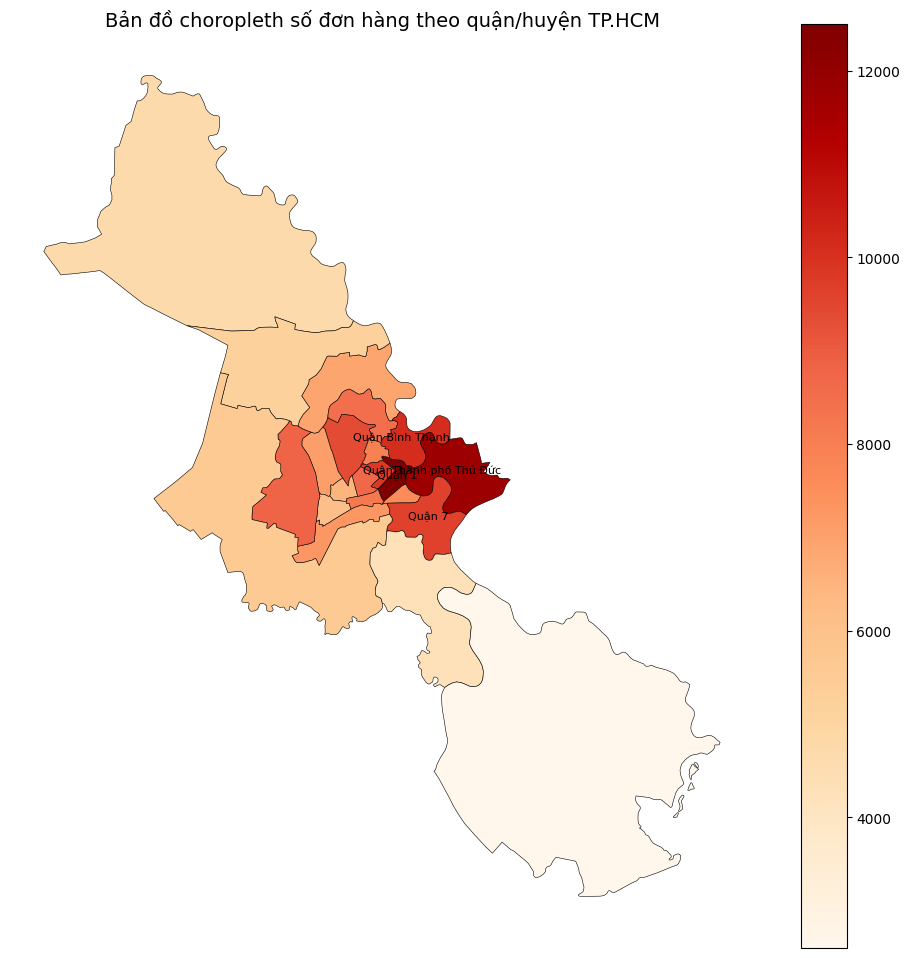

,district,orders
0,Quận 1,12500
1,Thành phố Thủ Đức,11800
2,Quận Bình Thạnh,10100
3,Quận 3,9800
4,Quận 7,9600
5,Quận Tân Bình,9400
6,Quận Bình Tân,8800
7,Quận 10,8700
8,Quận Gò Vấp,8500
9,Quận 5,8200


In [ ]:
#BT 23.4
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape
from IPython.display import display

url = "https://raw.githubusercontent.com/daohoangson/dvhcvn/master/data/gis/79.json"
response = requests.get(url, timeout=30)
response.raise_for_status()
hcm_json = response.json()

rows = []
for unit in hcm_json["level2s"]:
    geom = shape({
        "type": unit["type"],
        "coordinates": unit["coordinates"]
    })
    if not geom.is_valid:
        geom = geom.buffer(0)

    rows.append({
        "district": unit["name"],
        "geometry": geom
    })

gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")

metric_data = pd.DataFrame({
    "district": [
        "Quận 1", "Quận 3", "Quận 4", "Quận 5", "Quận 6", "Quận 7", "Quận 8",
        "Quận 10", "Quận 11", "Quận 12", "Quận Bình Thạnh", "Quận Phú Nhuận",
        "Quận Tân Bình", "Quận Tân Phú", "Quận Gò Vấp", "Quận Bình Tân",
        "Thành phố Thủ Đức", "Huyện Bình Chánh", "Huyện Củ Chi",
        "Huyện Hóc Môn", "Huyện Nhà Bè", "Huyện Cần Giờ"
    ],
    "orders": [
        12500, 9800, 7600, 8200, 6100, 9600, 7300,
        8700, 6500, 6900, 10100, 7900,
        9400, 7100, 8500, 8800,
        11800, 5600, 4700,
        5200, 4300, 2600
    ]
})

gdf = gdf.merge(metric_data, on="district", how="left")
gdf["orders"] = gdf["orders"].fillna(gdf["orders"].median())

fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    column="orders",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Không có dữ liệu"}
)

top5 = gdf.nlargest(5, "orders")
for _, row in top5.iterrows():
    p = row.geometry.representative_point()
    ax.text(p.x, p.y, row["district"], fontsize=8, ha="center")

ax.set_title("Bản đồ choropleth số đơn hàng theo quận/huyện TP.HCM", fontsize=14)
ax.axis("off")
plt.show()

display(
    gdf[["district", "orders"]]
    .sort_values("orders", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
BT 23.5
import pandas as pd
import folium
from geopy.distance import geodesic
from IPython.display import display

warehouse = (10.7769, 106.7009)

customers = {
    "KH01": (10.7780, 106.7020),
    "KH02": (10.7810, 106.7090),
    "KH03": (10.7730, 106.6890),
    "KH04": (10.7650, 106.6940),
    "KH05": (10.7580, 106.6820),
    "KH06": (10.7900, 106.7110),
    "KH07": (10.7510, 106.6740),
    "KH08": (10.8020, 106.7190),
    "KH09": (10.7430, 106.6680),
    "KH10": (10.7270, 106.7210),
    "KH11": (10.8150, 106.6900),
    "KH12": (10.7710, 106.6450),
    "KH13": (10.8460, 106.7720),
    "KH14": (10.7060, 106.7350),
    "KH15": (10.6890, 106.7480),
}

def classify_zone(distance_km):
    if distance_km <= 3:
        return "≤ 3 km"
    elif distance_km <= 5:
        return "3 - 5 km"
    elif distance_km <= 10:
        return "5 - 10 km"
    else:
        return "> 10 km"

rows = []
for name, coord in customers.items():
    dist = geodesic(warehouse, coord).km
    rows.append({
        "customer": name,
        "lat": coord[0],
        "lon": coord[1],
        "distance_km": round(dist, 2),
        "zone": classify_zone(dist)
    })

df_23_5 = pd.DataFrame(rows).sort_values("distance_km").reset_index(drop=True)

summary = (
    df_23_5["zone"]
    .value_counts()
    .reindex(["≤ 3 km", "3 - 5 km", "5 - 10 km", "> 10 km"], fill_value=0)
)

coverage_3 = round((df_23_5["distance_km"] <= 3).mean() * 100, 2)
coverage_5 = round((df_23_5["distance_km"] <= 5).mean() * 100, 2)
coverage_10 = round((df_23_5["distance_km"] <= 10).mean() * 100, 2)

print("Tỷ lệ khách hàng nằm trong từng mức bán kính:")
print(f"- Trong 3 km: {coverage_3}%")
print(f"- Trong 5 km: {coverage_5}%")
print(f"- Trong 10 km: {coverage_10}%")
print("\nSố khách theo từng vùng:")
print(summary)

zone_colors = {
    "≤ 3 km": "green",
    "3 - 5 km": "blue",
    "5 - 10 km": "purple",
    "> 10 km": "gray",
}

m = folium.Map(location=list(warehouse), zoom_start=12)

folium.Marker(
    warehouse,
    popup="Kho trung tâm",
    tooltip="Kho trung tâm",
    icon=folium.Icon(color="red", icon="home"),
).add_to(m)

folium.Circle(
    warehouse, radius=3000,
    color="green", fill=True, fill_opacity=0.05,
    popup="Vùng phục vụ 3 km"
).add_to(m)

folium.Circle(
    warehouse, radius=5000,
    color="blue", fill=True, fill_opacity=0.04,
    popup="Vùng phục vụ 5 km"
).add_to(m)

folium.Circle(
    warehouse, radius=10000,
    color="purple", fill=True, fill_opacity=0.03,
    popup="Vùng phục vụ 10 km"
).add_to(m)

for _, row in df_23_5.iterrows():
    popup_html = f"""
    <b>{row['customer']}</b><br>
    Khoảng cách tới kho: {row['distance_km']} km<br>
    Thuộc vùng: {row['zone']}
    """
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=row["customer"],
        icon=folium.Icon(color=zone_colors[row["zone"]]),
    ).add_to(m)

display(m)
display(df_23_5)

Tỷ lệ khách hàng nằm trong từng mức bán kính:
- Trong 3 km: 40.0%
- Trong 5 km: 60.0%
- Trong 10 km: 86.67%

Số khách theo từng vùng:
zone
≤ 3 km       6
3 - 5 km     3
5 - 10 km    4
> 10 km      2
Name: count, dtype: int64


,customer,lat,lon,distance_km,zone
0,KH01,10.778,106.702,0.17,≤ 3 km
1,KH02,10.781,106.709,1.00,≤ 3 km
2,KH03,10.773,106.689,1.37,≤ 3 km
3,KH04,10.765,106.694,1.52,≤ 3 km
4,KH06,10.790,106.711,1.82,≤ 3 km
5,KH05,10.758,106.682,2.94,≤ 3 km
6,KH08,10.802,106.719,3.41,3 - 5 km
7,KH07,10.751,106.674,4.11,3 - 5 km
8,KH11,10.815,106.690,4.38,3 - 5 km
9,KH09,10.743,106.668,5.20,5 - 10 km


In [ ]:
!pip -q install osmnx folium geopy networkx scikit-learn geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
#BT 23.06
import osmnx as ox
import networkx as nx
import folium
import geopandas as gpd
from IPython.display import display

place = "District 1, Ho Chi Minh City, Vietnam"

G = ox.graph_from_place(place, network_type="drive")

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

num_nodes = len(G.nodes)
num_edges = len(G.edges)

G_undirected = G.to_undirected()
intersection_count = sum(1 for _, deg in G_undirected.degree() if deg >= 3)

total_road_length_km = edges_gdf["length"].sum() / 1000
avg_road_length_m = edges_gdf["length"].mean()

place_gdf = ox.geocode_to_gdf(place).to_crs(epsg=3857)
area_km2 = place_gdf.geometry.area.iloc[0] / 1_000_000
network_density = total_road_length_km / area_km2

print("PHÂN TÍCH MẠNG GIAO THÔNG")
print(f"Số nút (nodes): {num_nodes}")
print(f"Số cạnh đường (edges): {num_edges}")
print(f"Số nút giao ước lượng: {intersection_count}")
print(f"Tổng chiều dài mạng đường: {total_road_length_km:.2f} km")
print(f"Chiều dài đường trung bình: {avg_road_length_m:.2f} m")
print(f"Mật độ mạng đường: {network_density:.2f} km/km²")

center_lat = nodes_gdf.geometry.y.mean()
center_lon = nodes_gdf.geometry.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

folium.GeoJson(
    edges_gdf[["geometry"]].to_json(),
    name="Mang duong",
    style_function=lambda x: {"color": "blue", "weight": 2}
).add_to(m)

sample_intersections = []
for node, deg in G_undirected.degree():
    if deg >= 3:
        sample_intersections.append(node)

for node in sample_intersections[:20]:
    y = G.nodes[node]["y"]
    x = G.nodes[node]["x"]
    folium.CircleMarker(
        location=[y, x],
        radius=3,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"Nút giao: {node}"
    ).add_to(m)

folium.LayerControl().add_to(m)
display(m)

PHÂN TÍCH MẠNG GIAO THÔNG
Số nút (nodes): 989
Số cạnh đường (edges): 2090
Số nút giao ước lượng: 808
Tổng chiều dài mạng đường: 165.17 km
Chiều dài đường trung bình: 79.03 m
Mật độ mạng đường: 20.57 km/km²


In [ ]:
#BT 23.7
import time
import osmnx as ox
import networkx as nx
import folium
from geopy.distance import geodesic
from IPython.display import display

place = "District 1, Ho Chi Minh City, Vietnam"
address_A = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
address_B = "Saigon Centre, Ho Chi Minh City, Vietnam"

ox.settings.use_cache = True
ox.settings.log_console = False

G = ox.graph_from_place(place, network_type="drive")

point_A = ox.geocode(address_A)
point_B = ox.geocode(address_B)

orig_node = ox.distance.nearest_nodes(G, point_A[1], point_A[0])
dest_node = ox.distance.nearest_nodes(G, point_B[1], point_B[0])

def heuristic(u, v):
    uy, ux = G.nodes[u]["y"], G.nodes[u]["x"]
    vy, vx = G.nodes[v]["y"], G.nodes[v]["x"]
    return geodesic((uy, ux), (vy, vx)).meters

def route_length_km(graph, route):
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        edge_data = graph.get_edge_data(u, v)
        best_edge = min(edge_data.values(), key=lambda d: d.get("length", 0))
        total += best_edge.get("length", 0)
    return total / 1000

t1 = time.perf_counter()
route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight="length", method="dijkstra")
t2 = time.perf_counter()

t3 = time.perf_counter()
route_astar = nx.astar_path(G, orig_node, dest_node, heuristic=heuristic, weight="length")
t4 = time.perf_counter()

distance_dijkstra = route_length_km(G, route_dijkstra)
distance_astar = route_length_km(G, route_astar)

time_dijkstra = (t2 - t1) * 1000
time_astar = (t4 - t3) * 1000

coords_dijkstra = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_dijkstra]
coords_astar = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_astar]

same_route = route_dijkstra == route_astar

print("KẾT QUẢ TÌM ĐƯỜNG")
print(f"Điểm A: {address_A}")
print(f"Điểm B: {address_B}")
print(f"Dijkstra: {distance_dijkstra:.2f} km | {len(route_dijkstra)} nút | {time_dijkstra:.3f} ms")
print(f"A*:       {distance_astar:.2f} km | {len(route_astar)} nút | {time_astar:.3f} ms")
print(f"Hai thuật toán cho cùng một tuyến: {same_route}")

center_map = [(point_A[0] + point_B[0]) / 2, (point_A[1] + point_B[1]) / 2]
m = folium.Map(location=center_map, zoom_start=15)

folium.Marker(point_A, popup="Điểm A", tooltip="Điểm A", icon=folium.Icon(color="red")).add_to(m)
folium.Marker(point_B, popup="Điểm B", tooltip="Điểm B", icon=folium.Icon(color="blue")).add_to(m)

folium.PolyLine(
    coords_dijkstra,
    color="green",
    weight=6,
    opacity=0.75,
    popup=f"Dijkstra: {distance_dijkstra:.2f} km"
).add_to(m)

folium.PolyLine(
    coords_astar,
    color="orange",
    weight=4,
    opacity=0.9,
    dash_array="10,8",
    popup=f"A*: {distance_astar:.2f} km"
).add_to(m)

display(m)

KẾT QUẢ TÌM ĐƯỜNG
Điểm A: Ben Thanh Market, Ho Chi Minh City, Vietnam
Điểm B: Saigon Centre, Ho Chi Minh City, Vietnam
Dijkstra: 0.40 km | 8 nút | 0.359 ms
A*:       0.40 km | 8 nút | 2.032 ms
Hai thuật toán cho cùng một tuyến: True


In [ ]:
#BT 23.8
import pandas as pd
import folium
from geopy.distance import geodesic
from IPython.display import display

drivers = {
    "Xe 1": (10.776, 106.700),
    "Xe 2": (10.782, 106.708),
    "Xe 3": (10.768, 106.690),
    "Xe 4": (10.758, 106.682),
    "Xe 5": (10.790, 106.720),
}

customers = {
    "Khách A": (10.780, 106.703),
    "Khách B": (10.765, 106.688),
    "Khách C": (10.755, 106.680),
    "Khách D": (10.788, 106.718),
    "Khách E": (10.774, 106.696),
}

available_drivers = drivers.copy()
assignments = []

for customer_name, customer_loc in customers.items():
    best_driver = None
    best_dist = float("inf")

    for driver_name, driver_loc in available_drivers.items():
        dist = geodesic(driver_loc, customer_loc).km
        if dist < best_dist:
            best_dist = dist
            best_driver = driver_name

    assignments.append({
        "Khách hàng": customer_name,
        "Xe được gán": best_driver,
        "Khoảng cách đón (km)": round(best_dist, 2),
        "Tọa độ khách": customer_loc,
        "Tọa độ xe": available_drivers[best_driver]
    })

    del available_drivers[best_driver]

df_assign = pd.DataFrame(assignments)
display(df_assign[["Khách hàng", "Xe được gán", "Khoảng cách đón (km)"]])

center = [10.775, 106.700]
m = folium.Map(location=center, zoom_start=14)

for name, loc in drivers.items():
    folium.Marker(
        loc,
        popup=f"{name} - Tài xế",
        tooltip=name,
        icon=folium.Icon(color="green", icon="car")
    ).add_to(m)

for _, row in df_assign.iterrows():
    customer_loc = row["Tọa độ khách"]
    driver_loc = row["Tọa độ xe"]

    folium.Marker(
        customer_loc,
        popup=f"{row['Khách hàng']}",
        tooltip=row["Khách hàng"],
        icon=folium.Icon(color="blue", icon="user")
    ).add_to(m)

    folium.PolyLine(
        [driver_loc, customer_loc],
        color="orange",
        weight=4,
        opacity=0.8,
        popup=f"{row['Xe được gán']} -> {row['Khách hàng']} ({row['Khoảng cách đón (km)']} km)"
    ).add_to(m)

display(m)
print(f"Tổng quãng đường đón khách: {df_assign['Khoảng cách đón (km)'].sum():.2f} km")

,Khách hàng,Xe được gán,Khoảng cách đón (km)
0,Khách A,Xe 1,0.55
1,Khách B,Xe 3,0.40
2,Khách C,Xe 4,0.40
3,Khách D,Xe 5,0.31
4,Khách E,Xe 2,1.58


Tổng quãng đường đón khách: 3.24 km


In [ ]:
#BT 23.9
import pandas as pd
import folium
from sklearn.cluster import KMeans
from IPython.display import display

data = pd.DataFrame([
    ["Đ1", 10.780, 106.702],
    ["Đ2", 10.781, 106.704],
    ["Đ3", 10.779, 106.700],
    ["Đ4", 10.776, 106.698],
    ["Đ5", 10.774, 106.697],
    ["Đ6", 10.767, 106.689],
    ["Đ7", 10.766, 106.688],
    ["Đ8", 10.768, 106.691],
    ["Đ9", 10.764, 106.686],
    ["Đ10", 10.762, 106.684],
    ["Đ11", 10.790, 106.718],
    ["Đ12", 10.791, 106.720],
    ["Đ13", 10.788, 106.716],
    ["Đ14", 10.786, 106.714],
    ["Đ15", 10.792, 106.722],
], columns=["order_id", "lat", "lon"])

k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(data[["lat", "lon"]])

centers = model.cluster_centers_
center_df = pd.DataFrame(centers, columns=["lat", "lon"])
center_df["station_name"] = [f"Trạm đề xuất {i+1}" for i in range(k)]

print("TÂM CỤM - VỊ TRÍ ĐỀ XUẤT")
display(center_df)

m = folium.Map(location=[data["lat"].mean(), data["lon"].mean()], zoom_start=14)

cluster_colors = {0: "red", 1: "blue", 2: "green", 3: "purple", 4: "orange"}

for _, row in data.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=cluster_colors[row["cluster"]],
        fill=True,
        fill_opacity=0.8,
        popup=f"{row['order_id']} - Cụm {row['cluster']}"
    ).add_to(m)

for _, row in center_df.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=row["station_name"],
        tooltip=row["station_name"],
        icon=folium.Icon(color="black", icon="home")
    ).add_to(m)

display(m)

cluster_summary = data.groupby("cluster").size().reset_index(name="Số đơn")
display(cluster_summary)

TÂM CỤM - VỊ TRÍ ĐỀ XUẤT


,lat,lon,station_name
0,10.7654,106.6876,Trạm đề xuất 1
1,10.7894,106.7180,Trạm đề xuất 2
2,10.7780,106.7002,Trạm đề xuất 3


,cluster,Số đơn
0,0,5
1,1,5
2,2,5


In [ ]:
#BT 23.10
import pandas as pd
import folium
import osmnx as ox
import networkx as nx
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from IPython.display import display

risk_points = pd.DataFrame([
    ["Nút A", 10.776, 106.699, 95, 12, 4],
    ["Nút B", 10.783, 106.703, 80, 18, 3],
    ["Nút C", 10.790, 106.690, 65, 22, 2],
    ["Nút D", 10.768, 106.684, 88, 14, 4],
    ["Nút E", 10.801, 106.667, 72, 20, 2],
], columns=["name", "lat", "lon", "traffic_volume", "avg_speed", "incidents"])

risk_points["vol_norm"] = (risk_points["traffic_volume"] - risk_points["traffic_volume"].min()) / (
    risk_points["traffic_volume"].max() - risk_points["traffic_volume"].min()
)
risk_points["speed_risk"] = 1 - (risk_points["avg_speed"] - risk_points["avg_speed"].min()) / (
    risk_points["avg_speed"].max() - risk_points["avg_speed"].min()
)
risk_points["inc_norm"] = (risk_points["incidents"] - risk_points["incidents"].min()) / (
    risk_points["incidents"].max() - risk_points["incidents"].min()
)

risk_points["risk_score"] = (
    0.45 * risk_points["vol_norm"] +
    0.35 * risk_points["speed_risk"] +
    0.20 * risk_points["inc_norm"]
)

def classify_risk(score):
    if score >= 0.7:
        return "Cao"
    elif score >= 0.4:
        return "Trung bình"
    else:
        return "Thấp"

risk_points["risk_level"] = risk_points["risk_score"].apply(classify_risk)
risk_points["influence_m"] = risk_points["risk_level"].map({
    "Cao": 800,
    "Trung bình": 500,
    "Thấp": 300
})

display(risk_points[["name", "traffic_volume", "avg_speed", "incidents", "risk_score", "risk_level"]])

geolocator = Nominatim(user_agent="colab_23_10", timeout=10)

start_address = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
end_address = "Tan Son Nhat International Airport, Ho Chi Minh City, Vietnam"

start_loc = geolocator.geocode(start_address)
end_loc = geolocator.geocode(end_address)

start_point = (start_loc.latitude, start_loc.longitude)
end_point = (end_loc.latitude, end_loc.longitude)

midpoint = ((start_point[0] + end_point[0]) / 2, (start_point[1] + end_point[1]) / 2)
G = ox.graph_from_point(midpoint, dist=7000, network_type="drive")

orig_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
dest_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

for u, v, k, data in G.edges(keys=True, data=True):
    length = data.get("length", 1.0)

    if "geometry" in data:
        midpoint_geom = data["geometry"].interpolate(0.5, normalized=True)
        edge_mid = (midpoint_geom.y, midpoint_geom.x)
    else:
        edge_mid = (
            (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2,
            (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        )

    penalty = 0
    for _, rp in risk_points.iterrows():
        d = geodesic(edge_mid, (rp["lat"], rp["lon"])).meters
        if d <= rp["influence_m"]:
            penalty = max(penalty, rp["risk_score"])

    data["risk_weight"] = length * (1 + 3 * penalty)

def route_length_m(route, weight_name="length"):
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)
        best_edge = min(edge_data.values(), key=lambda d: d.get(weight_name, d.get("length", 0)))
        total += best_edge.get(weight_name, best_edge.get("length", 0))
    return total

normal_route = nx.shortest_path(G, orig_node, dest_node, weight="length")
safe_route = nx.shortest_path(G, orig_node, dest_node, weight="risk_weight")

normal_km = route_length_m(normal_route, "length") / 1000
safe_km = route_length_m(safe_route, "length") / 1000

print(f"Tuyến ngắn nhất thông thường: {normal_km:.2f} km")
print(f"Tuyến đề xuất tránh rủi ro:   {safe_km:.2f} km")

coords_normal = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in normal_route]
coords_safe = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in safe_route]

m = folium.Map(location=midpoint, zoom_start=13)

folium.Marker(start_point, popup="Điểm đầu", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(end_point, popup="Điểm cuối", icon=folium.Icon(color="blue")).add_to(m)

risk_colors = {"Cao": "red", "Trung bình": "orange", "Thấp": "yellow"}

for _, row in risk_points.iterrows():
    folium.Circle(
        location=[row["lat"], row["lon"]],
        radius=row["influence_m"],
        color=risk_colors[row["risk_level"]],
        fill=True,
        fill_opacity=0.18,
        popup=f"{row['name']} | Risk={row['risk_level']} | Score={row['risk_score']:.2f}"
    ).add_to(m)

folium.PolyLine(
    coords_normal,
    color="gray",
    weight=4,
    opacity=0.7,
    popup=f"Tuyến thường: {normal_km:.2f} km"
).add_to(m)

folium.PolyLine(
    coords_safe,
    color="green",
    weight=6,
    opacity=0.85,
    popup=f"Tuyến đề xuất: {safe_km:.2f} km"
).add_to(m)

display(m)

,name,traffic_volume,avg_speed,incidents,risk_score,risk_level
0,Nút A,95,12,4,1.000,Cao
1,Nút B,80,18,3,0.465,Trung bình
2,Nút C,65,22,2,0.000,Thấp
3,Nút D,88,14,4,0.825,Cao
4,Nút E,72,20,2,0.175,Thấp


Tuyến ngắn nhất thông thường: 7.42 km
Tuyến đề xuất tránh rủi ro:   8.17 km


In [ ]:
!pip -q install folium osmnx networkx scikit-learn branca ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.4 MB/s eta 0:00:00


In [ ]:
#BT 23.11
import numpy as np
import pandas as pd
import folium
from branca.colormap import linear
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display

zones = pd.DataFrame({
    "zone": ["Quận 1", "Quận 3", "Bình Thạnh", "Thủ Đức", "Quận 7", "Tân Bình"],
    "lat": [10.776, 10.782, 10.810, 10.850, 10.734, 10.801],
    "lon": [106.700, 106.689, 106.710, 106.770, 106.721, 106.652],
    "zone_type": ["CBD", "Office", "Residential", "University", "Residential", "Airport"],
    "base_demand": [90, 70, 60, 75, 55, 65]
})

zone_code_map = {z: i for i, z in enumerate(zones["zone"])}
type_factor = {"CBD": 1.35, "Office": 1.20, "Residential": 0.95, "University": 1.15, "Airport": 1.25}

rows = []
rng = np.random.default_rng(42)

for day in range(28):
    dow = day % 7
    is_weekend = 1 if dow in [5, 6] else 0
    for hour in range(24):
        if 6 <= hour <= 8:
            time_factor = 1.20
        elif 11 <= hour <= 13:
            time_factor = 1.05
        elif 17 <= hour <= 20:
            time_factor = 1.40
        elif 0 <= hour <= 5:
            time_factor = 0.60
        else:
            time_factor = 0.85

        rain = int(rng.integers(0, 2))

        for _, z in zones.iterrows():
            if is_weekend == 1 and z["zone_type"] in ["Residential", "University"]:
                weekend_factor = 1.15
            elif is_weekend == 1 and z["zone_type"] in ["CBD", "Office"]:
                weekend_factor = 0.90
            else:
                weekend_factor = 1.00

            rain_factor = 1.18 if rain == 1 else 1.00
            noise = rng.normal(0, 6)

            demand = z["base_demand"] * type_factor[z["zone_type"]] * time_factor * weekend_factor * rain_factor + noise
            demand = max(5, demand)

            rows.append({
                "zone": z["zone"],
                "zone_code": zone_code_map[z["zone"]],
                "hour": hour,
                "is_weekend": is_weekend,
                "rain": rain,
                "demand": demand
            })

data = pd.DataFrame(rows)

X = data[["zone_code", "hour", "is_weekend", "rain"]]
y = data["demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

scenario = zones.copy()
scenario["zone_code"] = scenario["zone"].map(zone_code_map)
scenario["hour"] = 18
scenario["is_weekend"] = 0
scenario["rain"] = 0
scenario["predicted_demand"] = model.predict(scenario[["zone_code", "hour", "is_weekend", "rain"]])
scenario = scenario.sort_values("predicted_demand", ascending=False).reset_index(drop=True)

summary_frames = []
for h in [8, 12, 18, 21]:
    temp = zones.copy()
    temp["zone_code"] = temp["zone"].map(zone_code_map)
    temp["hour"] = h
    temp["is_weekend"] = 0
    temp["rain"] = 0
    temp["predicted_demand"] = model.predict(temp[["zone_code", "hour", "is_weekend", "rain"]])
    summary_frames.append(temp[["zone", "hour", "predicted_demand"]])

summary_table = pd.concat(summary_frames).pivot(index="zone", columns="hour", values="predicted_demand").round(1)

display(summary_table)

m = folium.Map(location=[zones["lat"].mean(), zones["lon"].mean()], zoom_start=11)

colormap = linear.YlOrRd_09.scale(scenario["predicted_demand"].min(), scenario["predicted_demand"].max())
colormap.caption = "Nhu cầu dự đoán lúc 18h ngày thường"

for _, row in scenario.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8 + row["predicted_demand"] / 18,
        color=colormap(row["predicted_demand"]),
        fill=True,
        fill_opacity=0.85,
        popup=f"{row['zone']} | Nhu cầu dự đoán: {row['predicted_demand']:.1f}",
        tooltip=row["zone"]
    ).add_to(m)

colormap.add_to(m)
display(m)

MAE: 5.10
R2: 0.965


hour,8,12,18,21
zone,,,,
Bình Thạnh,68.6,58.9,75.5,51.2
Quận 1,145.4,124.9,171.0,102.5
Quận 3,101.1,83.5,118.0,69.9
Quận 7,61.2,54.3,73.6,48.6
Thủ Đức,103.1,92.2,118.7,76.0
Tân Bình,95.7,84.7,114.0,70.1


In [ ]:
#BT 23.12
import pandas as pd
import folium
from geopy.distance import geodesic
from IPython.display import display

warehouses = {
    "Kho A": (10.776, 106.700),
    "Kho B": (10.792, 106.720)
}

customers = {
    "Đơn 1": (10.764, 106.686),
    "Đơn 2": (10.783, 106.709),
    "Đơn 3": (10.770, 106.692),
    "Đơn 4": (10.780, 106.704),
    "Đơn 5": (10.799, 106.731),
    "Đơn 6": (10.788, 106.716),
    "Đơn 7": (10.786, 106.722),
    "Đơn 8": (10.796, 106.726)
}

def route_distance(path):
    total = 0
    for i in range(len(path) - 1):
        total += geodesic(path[i], path[i + 1]).km
    return total

def nearest_neighbor_route(start, stops):
    remaining = stops.copy()
    current = start
    route = [start]
    visit_order = []

    while remaining:
        next_name, next_loc = min(remaining.items(), key=lambda x: geodesic(current, x[1]).km)
        route.append(next_loc)
        visit_order.append(next_name)
        current = next_loc
        del remaining[next_name]

    route.append(start)
    return route, visit_order

assign_rows = []
for customer_name, customer_loc in customers.items():
    nearest_wh = min(warehouses.items(), key=lambda x: geodesic(customer_loc, x[1]).km)[0]
    assign_rows.append({
        "Điểm giao": customer_name,
        "Kho phụ trách": nearest_wh,
        "Tọa độ": customer_loc
    })

assign_df = pd.DataFrame(assign_rows)
display(assign_df[["Điểm giao", "Kho phụ trách"]])

result_rows = []
map_data = []

for warehouse_name, warehouse_loc in warehouses.items():
    assigned = assign_df[assign_df["Kho phụ trách"] == warehouse_name].reset_index(drop=True)

    naive_path = [warehouse_loc] + assigned["Tọa độ"].tolist() + [warehouse_loc]
    naive_distance = route_distance(naive_path)

    stop_dict = {row["Điểm giao"]: row["Tọa độ"] for _, row in assigned.iterrows()}
    opt_path, visit_order = nearest_neighbor_route(warehouse_loc, stop_dict)
    opt_distance = route_distance(opt_path)

    improvement = 0
    if naive_distance > 0:
        improvement = (naive_distance - opt_distance) / naive_distance * 100

    result_rows.append({
        "Kho": warehouse_name,
        "Số điểm giao": len(assigned),
        "Quãng đường không tối ưu (km)": round(naive_distance, 2),
        "Quãng đường tối ưu heuristic (km)": round(opt_distance, 2),
        "Tỷ lệ cải thiện (%)": round(improvement, 2),
        "Thứ tự giao heuristic": " -> ".join(visit_order)
    })

    map_data.append({
        "warehouse": warehouse_name,
        "naive_path": naive_path,
        "opt_path": opt_path
    })

result_df = pd.DataFrame(result_rows)
display(result_df)

total_naive = result_df["Quãng đường không tối ưu (km)"].sum()
total_opt = result_df["Quãng đường tối ưu heuristic (km)"].sum()
total_improve = (total_naive - total_opt) / total_naive * 100

print(f"Tổng quãng đường không tối ưu: {total_naive:.2f} km")
print(f"Tổng quãng đường tối ưu: {total_opt:.2f} km")
print(f"Tỷ lệ cải thiện toàn hệ thống: {total_improve:.2f}%")

m = folium.Map(location=[10.782, 106.708], zoom_start=13)

warehouse_colors = {"Kho A": "red", "Kho B": "blue"}

for warehouse_name, warehouse_loc in warehouses.items():
    folium.Marker(
        warehouse_loc,
        popup=warehouse_name,
        tooltip=warehouse_name,
        icon=folium.Icon(color=warehouse_colors[warehouse_name], icon="home")
    ).add_to(m)

for customer_name, customer_loc in customers.items():
    wh = assign_df.loc[assign_df["Điểm giao"] == customer_name, "Kho phụ trách"].values[0]
    folium.Marker(
        customer_loc,
        popup=f"{customer_name} | {wh}",
        tooltip=customer_name,
        icon=folium.Icon(color=warehouse_colors[wh])
    ).add_to(m)

for item in map_data:
    folium.PolyLine(
        item["naive_path"],
        color="gray",
        weight=3,
        opacity=0.7,
        dash_array="6,8",
        popup=f"{item['warehouse']} - Tuyến không tối ưu"
    ).add_to(m)

    folium.PolyLine(
        item["opt_path"],
        color=warehouse_colors[item["warehouse"]],
        weight=5,
        opacity=0.85,
        popup=f"{item['warehouse']} - Tuyến tối ưu heuristic"
    ).add_to(m)

display(m)

,Điểm giao,Kho phụ trách
0,Đơn 1,Kho A
1,Đơn 2,Kho A
2,Đơn 3,Kho A
3,Đơn 4,Kho A
4,Đơn 5,Kho B
5,Đơn 6,Kho B
6,Đơn 7,Kho B
7,Đơn 8,Kho B


,Kho,Số điểm giao,Quãng đường không tối ưu (km),Quãng đường tối ưu heuristic (km),Tỷ lệ cải thiện (%),Thứ tự giao heuristic
0,Kho A,4,9.99,6.57,34.24,Đơn 4 -> Đơn 2 -> Đơn 3 -> Đơn 1
1,Kho B,4,6.15,4.57,25.58,Đơn 6 -> Đơn 7 -> Đơn 8 -> Đơn 5


Tổng quãng đường không tối ưu: 16.14 km
Tổng quãng đường tối ưu: 11.14 km
Tỷ lệ cải thiện toàn hệ thống: 30.98%


In [ ]:
#BT 23.13
import folium
import pandas as pd
from folium.plugins import HeatMap, MarkerCluster, MiniMap, Fullscreen
from IPython.display import display

warehouses = pd.DataFrame([
    ["Kho trung tâm", 10.776, 106.700],
    ["Kho vệ tinh Đông", 10.791, 106.720],
    ["Kho vệ tinh Tây", 10.768, 106.686]
], columns=["name", "lat", "lon"])

stores = pd.DataFrame([
    ["Cửa hàng 1", 10.781, 106.704, "Đang hoạt động"],
    ["Cửa hàng 2", 10.774, 106.697, "Đang hoạt động"],
    ["Cửa hàng 3", 10.788, 106.716, "Quá tải"],
    ["Cửa hàng 4", 10.765, 106.688, "Đang hoạt động"]
], columns=["name", "lat", "lon", "status"])

routes = {
    "Tuyến Bắc": [(10.776, 106.700), (10.783, 106.709), (10.791, 106.720)],
    "Tuyến Tây": [(10.776, 106.700), (10.770, 106.692), (10.764, 106.686)],
    "Tuyến Đông": [(10.776, 106.700), (10.780, 106.704), (10.788, 106.716)]
}

heat_points = [
    [10.780, 106.704, 28],
    [10.781, 106.703, 24],
    [10.779, 106.700, 31],
    [10.776, 106.698, 20],
    [10.767, 106.689, 18],
    [10.766, 106.688, 17],
    [10.788, 106.716, 26],
    [10.791, 106.720, 22]
]

service_areas = [
    {"name": "Vùng phục vụ kho trung tâm", "center": [10.776, 106.700], "radius": 2500, "color": "blue"},
    {"name": "Vùng phục vụ phía Đông", "center": [10.791, 106.720], "radius": 1800, "color": "green"},
    {"name": "Vùng phục vụ phía Tây", "center": [10.768, 106.686], "radius": 1800, "color": "purple"}
]

m = folium.Map(location=[10.779, 106.703], zoom_start=13)

Fullscreen().add_to(m)
MiniMap(toggle_display=True).add_to(m)

points_layer = folium.FeatureGroup(name="Lớp điểm")
zones_layer = folium.FeatureGroup(name="Lớp vùng")
routes_layer = folium.FeatureGroup(name="Lớp tuyến đường")
heat_layer = folium.FeatureGroup(name="Lớp nhiệt nhu cầu")

cluster = MarkerCluster().add_to(points_layer)

for _, row in warehouses.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=row["name"],
        tooltip=row["name"],
        icon=folium.Icon(color="red", icon="home")
    ).add_to(cluster)

for _, row in stores.iterrows():
    color = "green" if row["status"] == "Đang hoạt động" else "orange"
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=f"{row['name']} | {row['status']}",
        tooltip=row["name"],
        icon=folium.Icon(color=color, icon="shopping-cart")
    ).add_to(cluster)

for zone in service_areas:
    folium.Circle(
        location=zone["center"],
        radius=zone["radius"],
        color=zone["color"],
        fill=True,
        fill_opacity=0.08,
        popup=zone["name"]
    ).add_to(zones_layer)

route_colors = {"Tuyến Bắc": "blue", "Tuyến Tây": "purple", "Tuyến Đông": "orange"}

for route_name, coords in routes.items():
    folium.PolyLine(
        coords,
        color=route_colors[route_name],
        weight=5,
        opacity=0.85,
        popup=route_name
    ).add_to(routes_layer)

HeatMap(heat_points, radius=24, blur=18, min_opacity=0.35).add_to(heat_layer)

points_layer.add_to(m)
zones_layer.add_to(m)
routes_layer.add_to(m)
heat_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
display(m)

In [ ]:
#BT 23.14
import pandas as pd
import folium
from IPython.display import display

vehicles = {
    "Xe 1": [(10.776, 106.700), (10.780, 106.704), (10.786, 106.709), (10.776, 106.700)],
    "Xe 2": [(10.768, 106.686), (10.770, 106.692), (10.774, 106.697), (10.768, 106.686)],
    "Xe 3": [(10.791, 106.720), (10.788, 106.716), (10.796, 106.726), (10.791, 106.720)]
}

time_labels = ["08:00", "08:10", "08:20", "08:30", "08:40", "08:50", "09:00"]

vehicle_colors = {
    "Xe 1": "red",
    "Xe 2": "blue",
    "Xe 3": "green"
}

def interpolate(p1, p2, t):
    return (
        p1[0] + (p2[0] - p1[0]) * t,
        p1[1] + (p2[1] - p1[1]) * t
    )

def get_vehicle_state(path, step, total_steps):
    num_segments = len(path) - 1
    progress = step / (total_steps - 1) * num_segments
    segment_index = min(int(progress), num_segments - 1)
    local_t = progress - segment_index
    position = interpolate(path[segment_index], path[segment_index + 1], local_t)

    if segment_index == 0:
        status = "Đang đi tới điểm giao thứ nhất"
    elif segment_index < num_segments - 1:
        status = f"Đang thực hiện điểm giao thứ {segment_index + 1}"
    else:
        status = "Đang quay về kho"

    return position, status

def state_table(step):
    rows = []
    for vehicle_name, path in vehicles.items():
        pos, status = get_vehicle_state(path, step, len(time_labels))
        rows.append({
            "Xe": vehicle_name,
            "Thời điểm": time_labels[step],
            "Vĩ độ": round(pos[0], 6),
            "Kinh độ": round(pos[1], 6),
            "Trạng thái": status
        })
    return pd.DataFrame(rows)

def render_map(step):
    m = folium.Map(location=[10.779, 106.703], zoom_start=13)

    for vehicle_name, path in vehicles.items():
        color = vehicle_colors[vehicle_name]

        folium.PolyLine(
            path,
            color=color,
            weight=4,
            opacity=0.55,
            popup=f"Lộ trình {vehicle_name}"
        ).add_to(m)

        folium.Marker(
            path[0],
            popup=f"{vehicle_name} - Kho xuất phát",
            icon=folium.Icon(color=color, icon="home")
        ).add_to(m)

        pos, status = get_vehicle_state(path, step, len(time_labels))

        folium.Marker(
            pos,
            popup=f"{vehicle_name} | {status} | {time_labels[step]}",
            tooltip=vehicle_name,
            icon=folium.Icon(color=color, icon="car")
        ).add_to(m)

    return m

for step in range(len(time_labels)):
    print(f"TRẠNG THÁI HỆ THỐNG TẠI {time_labels[step]}")
    display(state_table(step))
    display(render_map(step))

TRẠNG THÁI HỆ THỐNG TẠI 08:00


,Xe,Thời điểm,Vĩ độ,Kinh độ,Trạng thái
0,Xe 1,08:00,10.776,106.700,Đang đi tới điểm giao thứ nhất
1,Xe 2,08:00,10.768,106.686,Đang đi tới điểm giao thứ nhất
2,Xe 3,08:00,10.791,106.720,Đang đi tới điểm giao thứ nhất


TRẠNG THÁI HỆ THỐNG TẠI 08:10


,Xe,Thời điểm,Vĩ độ,Kinh độ,Trạng thái
0,Xe 1,08:10,10.7780,106.702,Đang đi tới điểm giao thứ nhất
1,Xe 2,08:10,10.7690,106.689,Đang đi tới điểm giao thứ nhất
2,Xe 3,08:10,10.7895,106.718,Đang đi tới điểm giao thứ nhất


TRẠNG THÁI HỆ THỐNG TẠI 08:20


...

,Xe,Thời điểm,Vĩ độ,Kinh độ,Trạng thái
0,Xe 1,08:40,10.786,106.709,Đang quay về kho
1,Xe 2,08:40,10.774,106.697,Đang quay về kho
2,Xe 3,08:40,10.796,106.726,Đang quay về kho


TRẠNG THÁI HỆ THỐNG TẠI 08:50


,Xe,Thời điểm,Vĩ độ,Kinh độ,Trạng thái
0,Xe 1,08:50,10.7810,106.7045,Đang quay về kho
1,Xe 2,08:50,10.7710,106.6915,Đang quay về kho
2,Xe 3,08:50,10.7935,106.7230,Đang quay về kho


TRẠNG THÁI HỆ THỐNG TẠI 09:00


,Xe,Thời điểm,Vĩ độ,Kinh độ,Trạng thái
0,Xe 1,09:00,10.776,106.700,Đang quay về kho
1,Xe 2,09:00,10.768,106.686,Đang quay về kho
2,Xe 3,09:00,10.791,106.720,Đang quay về kho


In [25]:
!pip -q install folium geopy ipywidgets

In [26]:
from google.colab import output
output.enable_custom_widget_manager()

In [40]:
import folium
import ipywidgets as widgets
import osmnx as ox
import networkx as nx
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from IPython.display import display, clear_output

# Configure osmnx
ox.settings.use_cache = True
ox.settings.log_console = False

geolocator = Nominatim(user_agent="smart_delivery_route_v4", timeout=10)

title = widgets.HTML("""
<div style="
    background: linear-gradient(135deg, #0f172a, #334155);
    color: white;
    padding: 18px 22px;
    border-radius: 16px;
    font-family: Arial;
    box-shadow: 0 6px 18px rgba(0,0,0,0.15);
">
    <div style="font-size: 28px; font-weight: 700;">Smart Delivery Route App</div>
    <div style="font-size: 14px; margin-top: 6px;">
        Tính toán lộ trình thực tế & Chi phí vận chuyển
    </div>
</div>
""")

pickup_input = widgets.Text(description="Điểm lấy", placeholder="Ví dụ: Chợ Bến Thành", layout=widgets.Layout(width="760px"))
dropoff_input = widgets.Text(description="Điểm giao", placeholder="Ví dụ: Landmark 81", layout=widgets.Layout(width="760px"))

vehicle_dropdown = widgets.Dropdown(
    description="Phương tiện",
    options=["Xe máy", "Ô tô", "Đi bộ"],
    value="Xe máy",
    layout=widgets.Layout(width="300px")
)

service_time_slider = widgets.IntSlider(value=5, min=0, max=30, description="Bốc dỡ", layout=widgets.Layout(width="400px"))

sample_button = widgets.Button(description="Điền mẫu", button_style="info", icon="edit")
calc_button = widgets.Button(description="Tính tuyến đường", button_style="success", icon="map")
clear_button = widgets.Button(description="Xóa", button_style="warning", icon="trash")

status_box = widgets.HTML("<div style='padding:12px; border-radius:10px; background:#f1f5f9;'>Sẵn sàng.</div>")
result_box = widgets.HTML("")
map_output = widgets.Output()

profile_to_network = {"Xe máy": "drive", "Ô tô": "drive", "Đi bộ": "walk"}
profile_to_speed = {"Xe máy": 22, "Ô tô": 28, "Đi bộ": 4.5}
cost_per_km = {"Xe máy": 5000, "Ô tô": 15000, "Đi bộ": 0}

def geocode_safe(address):
    try:
        loc = geolocator.geocode(address)
        return (loc.latitude, loc.longitude, loc.address) if loc else None
    except: return None

def calculate_route(start_coords, end_coords, mode):
    direct_dist = geodesic(start_coords, end_coords).meters
    center_point = ((start_coords[0] + end_coords[0])/2, (start_coords[1] + end_coords[1])/2)
    network_type = profile_to_network.get(mode, "drive")
    G = ox.graph_from_point(center_point, dist=direct_dist + 2000, network_type=network_type)
    orig_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
    dest_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
    route = nx.shortest_path(G, orig_node, dest_node, weight="length")

    route_coords = []
    total_length = 0
    for u, v in zip(route[:-1], route[1:]):
        data = min(G.get_edge_data(u, v).values(), key=lambda x: x['length'])
        if 'geometry' in data:
            route_coords.extend(list(data['geometry'].coords))
        else:
            route_coords.append((G.nodes[u]['x'], G.nodes[u]['y']))
            route_coords.append((G.nodes[v]['x'], G.nodes[v]['y']))
        total_length += data['length']

    final_path = [(lat, lon) for lon, lat in route_coords]
    return final_path, total_length / 1000

def calculate(_):
    map_output.clear_output()
    p_addr, d_addr = pickup_input.value.strip(), dropoff_input.value.strip()
    mode = vehicle_dropdown.value

    if not p_addr or not d_addr:
        status_box.value = "Vui lòng nhập địa chỉ!"; return

    status_box.value = "<div style='color:blue;'>Đang tính toán lộ trình...</div>"
    p_loc, d_loc = geocode_safe(p_addr), geocode_safe(d_addr)

    if not p_loc or not d_loc:
        status_box.value = "Lỗi tìm địa chỉ!"; return

    try:
        path, dist_km = calculate_route((p_loc[0], p_loc[1]), (d_loc[0], d_loc[1]), mode)
        move_t = (dist_km / profile_to_speed[mode]) * 60
        cost = dist_km * cost_per_km[mode]

        result_box.value = f"""
        <div style="font-family: Arial; margin-top: 15px;">
            <div style="padding: 10px; background: #f8fafc; border-left: 5px solid #64748b; margin-bottom: 10px; border-radius: 4px;">
                <div style="font-size: 13px; color: #64748b;"><b>Từ:</b> {p_loc[2]}</div>
                <div style="font-size: 13px; color: #64748b;"><b>Đến:</b> {d_loc[2]}</div>
            </div>
            <div style="display:flex; gap:10px;">
                <div style="flex:1; padding:15px; background:#e0f2fe; border-radius:10px; border:2px solid #0ea5e9; text-align: center;">
                    <div style="color: #0369a1; font-size: 14px;">QUÃNG ĐƯỜNG</div>
                    <div style="color: #0c4a6e; font-size: 20px; font-weight: 800;">{dist_km:.2f} km</div>
                </div>
                <div style="flex:1; padding:15px; background:#dcfce7; border-radius:10px; border:2px solid #22c55e; text-align: center;">
                    <div style="color: #15803d; font-size: 14px;">THỜI GIAN</div>
                    <div style="color: #064e3b; font-size: 20px; font-weight: 800;">{move_t + service_time_slider.value:.1f} phút</div>
                </div>
                <div style="flex:1; padding:15px; background:#ffedd5; border-radius:10px; border:2px solid #f97316; text-align: center;">
                    <div style="color: #c2410c; font-size: 14px;">PHÍ SHIP</div>
                    <div style="color: #7c2d12; font-size: 20px; font-weight: 800;">{cost:,.0f} VNĐ</div>
                </div>
            </div>
        </div>
        """

        m = folium.Map(location=[p_loc[0], p_loc[1]], zoom_start=14)

        folium.Marker((p_loc[0], p_loc[1]), popup="Lấy: "+p_loc[2], icon=folium.Icon(color='blue', icon='info-sign')).add_to(m)
        folium.Marker((d_loc[0], d_loc[1]), popup="Giao: "+d_loc[2], icon=folium.Icon(color='green', icon='home')).add_to(m)
        folium.PolyLine(path, color="blue", weight=6, opacity=0.7).add_to(m)

        with map_output: display(m)
        status_box.value = "<div style='color:green;'>Sẵn sàng!</div>"
    except Exception as e:
        status_box.value = f"<div style='color:red;'>Lỗi: {str(e)}</div>"

sample_button.on_click(lambda _: setattr(pickup_input, 'value', 'Chợ Bến Thành') or setattr(dropoff_input, 'value', 'Bitexco Financial Tower'))
calc_button.on_click(calculate)
clear_button.on_click(lambda _: [setattr(pickup_input, 'value', ''), setattr(dropoff_input, 'value', ''), result_box.set_trait('value', ''), map_output.clear_output()])

display(widgets.VBox([title, pickup_input, dropoff_input, widgets.HBox([vehicle_dropdown, service_time_slider]), widgets.HBox([sample_button, calc_button, clear_button]), status_box, result_box, map_output]))